# E-Commerce Conversion Prediction
### Summer Analytics 2026 — Mini Hackathon | IIT Guwahati C&A Club

---

The goal of this project is to predict whether a user on an e-commerce platform will **convert** (i.e., make a purchase) or not, based on behavioral and demographic features.

This is a **binary classification problem**:
- `1` → User converted (made a purchase)
- `0` → User did not convert

I'll be walking through the full pipeline — loading data, exploring it, cleaning it up, building a model, and finally generating predictions for submission.

Let's get into it.

## Step 1 — Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 — Loading the Datasets

Loading all three datasets provided:

- **train.csv** → has features + target (`Converted`), used to train the model
- **public_test.csv** → has features + target, used to validate and tune
- **private_test.csv** → has features only, this is what I need to predict and submit

In [2]:
train = pd.read_csv("data/train.csv")
public_test = pd.read_csv("data/public_test.csv")
private_test = pd.read_csv("data/private_test.csv")

print("Train shape      :", train.shape)
print("Public Test shape:", public_test.shape)
print("Private Test shape:", private_test.shape)

Train shape      : (10000, 14)
Public Test shape: (3000, 14)
Private Test shape: (3000, 13)


## Step 3 — Exploratory Data Analysis (EDA)

Let's first see our data properly.


- The first few rows to get a feel for the data
- Data types of each column
- Missing values — which columns have them and how many
- The balance of the target variable (how many 1s vs 0s)
- Basic statistics to spot anything unusual

In [4]:
train.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  object 
 5   Traffic_Source      10000 non-null  object 
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


In [6]:
missing = train.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:\n")
print(missing)

Columns with missing values:

Age             1480
Income           984
Time_On_Site    1848
dtype: int64


In [7]:
print("Target Variable Distribution:\n")
print(train['Converted'].value_counts())
print()
print("As percentages:")
print(train['Converted'].value_counts(normalize=True).round(2) * 100)

Target Variable Distribution:

Converted
0    6913
1    3087
Name: count, dtype: int64

As percentages:
Converted
0    69.0
1    31.0
Name: proportion, dtype: float64


### Observations so far:

- Dataset has **10,000 rows** and **14 columns**
- Three columns have missing values: `Age` (~ 14.8%), `Income` (~ 9.8%), and `Time_On_Site` (~18.5%)
- The target is **imbalanced** — about 69% users did NOT convert, and 31% did
- This is why the evaluation metric is **F1 Score** and not plain accuracy — F1 handles imbalance better

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,10000.0,5000.500000,2886.895680,1.0,2500.750000,5000.500000,7500.250000,10000.000000
Age,8520.0,41.457746,13.770164,18.0,29.000000,41.000000,53.000000,65.000000
Income,9016.0,69961.772797,24790.673822,12000.0,52294.644359,70171.613672,86907.747154,161687.774167
City_Tier,10000.0,1.933400,0.737712,1.0,1.000000,2.000000,2.000000,3.000000
Pages_Viewed,10000.0,15.608500,8.623460,1.0,8.000000,16.000000,23.000000,30.000000
Products_Viewed,10000.0,15.219300,8.927563,1.0,8.000000,15.000000,23.000000,37.000000
Time_On_Site,8152.0,13.667241,19.438244,0.8,7.640000,11.145000,15.630000,607.390000
Previous_Purchases,10000.0,2.972500,1.738691,0.0,2.000000,3.000000,4.000000,12.000000
Discount_Seen,10000.0,0.540700,0.498366,0.0,0.000000,1.000000,1.000000,1.000000
Browser_Version,10000.0,12.473900,6.892856,1.0,7.000000,12.000000,18.000000,24.000000


### Something worth noting:

The maximum value of `Time_On_Site` is **607 minutes** — that's over 10 hours on a single session!
The average is only about 13 minutes, so this looks like an **outlier**.
I'll keep this in mind during preprocessing.

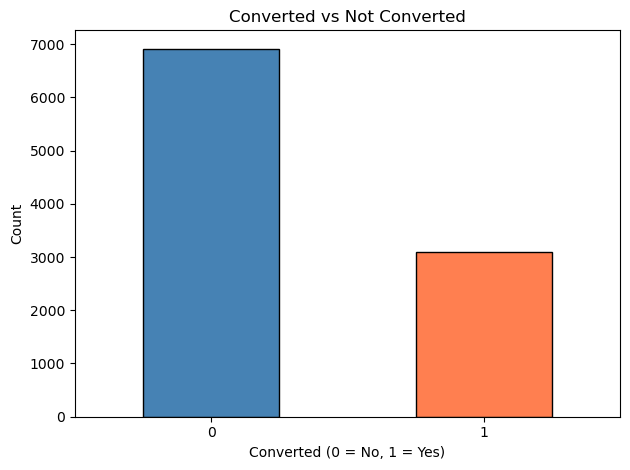

In [11]:
train['Converted'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Converted vs Not Converted')
plt.xlabel('Converted (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing

Raw data is almost never ready to be fed directly into a model.
I need to clean it up first.

- **Handling missing values** → fill them with the median of each column
- **Handling outliers** → cap the extreme value in `Time_On_Site`
- **Encoding categorical columns** → convert text columns into numbers since ML models only understand numbers

Applying the same transformations to all three datasets (train, public_test, private_test)

### 4.1 — Handling Missing Values

The three columns with missing values are `Age`, `Income`, and `Time_On_Site`.
I'll fill each one with the **median** of that column from the training data.

Why median and not mean?
Because as we know, median is not affected by outliers — and we already know `Time_On_Site` has one.

In [12]:
age_median = train['Age'].median()
income_median = train['Income'].median()
time_median = train['Time_On_Site'].median()

print("Age median      :", age_median)
print("Income median   :", income_median)
print("Time_On_Site median:", time_median)

Age median      : 41.0
Income median   : 70171.61367150277
Time_On_Site median: 11.145


In [13]:
for df in [train, public_test, private_test]:
    df['Age'].fillna(age_median, inplace=True)
    df['Income'].fillna(income_median, inplace=True)
    df['Time_On_Site'].fillna(time_median, inplace=True)

# Verify no missing values remain
print("Missing values in train after filling:")
print(train.isnull().sum())

Missing values in train after filling:
User_ID               0
Age                   0
Income                0
City_Tier             0
Device_Type           0
Traffic_Source        0
Pages_Viewed          0
Products_Viewed       0
Time_On_Site          0
Previous_Purchases    0
Discount_Seen         0
Browser_Version       0
Campaign_Code         0
Converted             0
dtype: int64


### 4.2 — Handling Outliers

`Time_On_Site` had a maximum value of 607 minutes which is clearly unrealistic.
Instead of removing that row entirely, I'll **cap** it at the 99th percentile value.

This way I don't lose data — I just bring the extreme value back to a reasonable range.

In [15]:
cap_value = train['Time_On_Site'].quantile(0.99)
print("Capping Time_On_Site at:", cap_value)

for df in [train, public_test, private_test]:
    df['Time_On_Site'] = df['Time_On_Site'].clip(upper=cap_value)

print("\nMax Time_On_Site after capping:", train['Time_On_Site'].max())

Capping Time_On_Site at: 37.64040000000001

Max Time_On_Site after capping: 37.64040000000001


### 4.3 — Encoding Categorical Columns

Machine learning models can't work with text — they need numbers.

Two columns need to be encoded:
- `Device_Type` → Mobile, Desktop, Tablet
- `Traffic_Source` → Organic, Social Media, Referral, Email, Paid Ads

I'll use **Label Encoding** — which simply assigns a number to each unique category.

In [18]:
le_device = LabelEncoder()
le_traffic = LabelEncoder()

# Fit on train data and transform all three datasets
train['Device_Type'] = le_device.fit_transform(train['Device_Type'])
public_test['Device_Type'] = le_device.transform(public_test['Device_Type'])
private_test['Device_Type'] = le_device.transform(private_test['Device_Type'])



train['Traffic_Source'] = le_traffic.fit_transform(train['Traffic_Source'])
public_test['Traffic_Source'] = le_traffic.transform(public_test['Traffic_Source'])
private_test['Traffic_Source'] = le_traffic.transform(private_test['Traffic_Source'])

print("Device_Type encoding  :", dict(zip(le_device.classes_, le_device.transform(le_device.classes_))))
print("Traffic_Source encoding:", dict(zip(le_traffic.classes_, le_traffic.transform(le_traffic.classes_))))

Device_Type encoding  : {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
Traffic_Source encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}


### 4.4 — Defining Features and Target

Now I'll separate the columns into:
- **X** → the input features the model will learn from
- **y** → the target column it's trying to predict

I'll drop `User_ID` from features since it's just an identifier — it carries no useful information for prediction.

In [19]:
drop_cols = ['User_ID', 'Converted']

X_train = train.drop(columns=drop_cols)
y_train = train['Converted']

X_public = public_test.drop(columns=drop_cols)
y_public = public_test['Converted']

X_private = private_test.drop(columns=['User_ID'])

print("X_train shape :", X_train.shape)
print("X_public shape:", X_public.shape)
print("X_private shape:", X_private.shape)

X_train shape : (10000, 12)
X_public shape: (3000, 12)
X_private shape: (3000, 12)


### Preprocessing Complete

At this point the data is:
- Free of missing values 
- Outliers handled 
- All columns are numeric 
- Features and target are separated 

The data is now ready to be fed into a machine learning model.

## Step 5 — Model Training

Now that the data is clean and ready, it's time to build the actual prediction model.

Using a **Random Forest Classifier** .

### Why Random Forest?
- It builds multiple decision trees and combines their results — this reduces overfitting
- It handles numerical and categorical (encoded) data well
- It gives us **feature importance** — telling us which columns matter most for prediction
- It works well even without heavy tuning as a first model

I'll train it on `X_train` and `y_train`.

### 5.1 — Training the Random Forest Model

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    random_state=42,       # for reproducibility
    class_weight='balanced' # handles our 69/31 class imbalance
)

rf_model.fit(X_train, y_train)

print("Model training complete!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Features used  : {list(X_train.columns)}")

Model training complete!
Number of trees: 100
Features used  : ['Age', 'Income', 'City_Tier', 'Device_Type', 'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Campaign_Code']


### 5.2 — Evaluating on Public Test Set

Now, checking how the model performs on `public_test` — this is our validation set.

The key metric here is **F1 Score** since that's what the competition uses.

F1 Score combines two things:
- **Precision** → out of all users predicted to convert, how many actually did?
- **Recall** → out of all users who actually converted, how many did we catch?

A high F1 means the model is doing well on both.

In [21]:
y_pred_public = rf_model.predict(X_public)

f1 = f1_score(y_public, y_pred_public)
print(f"F1 Score on Public Test: {f1:.4f}")
print()
print("Detailed Report:")
print(classification_report(y_public, y_pred_public))

F1 Score on Public Test: 0.3084

Detailed Report:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81      2114
           1       0.49      0.23      0.31       886

    accuracy                           0.70      3000
   macro avg       0.61      0.56      0.56      3000
weighted avg       0.66      0.70      0.66      3000



### 5.3 — Feature Importance

One of the best things about Random Forest is that it tells us
**which features contributed the most** to the predictions.

This helps us understand the data better — and can guide future feature engineering.

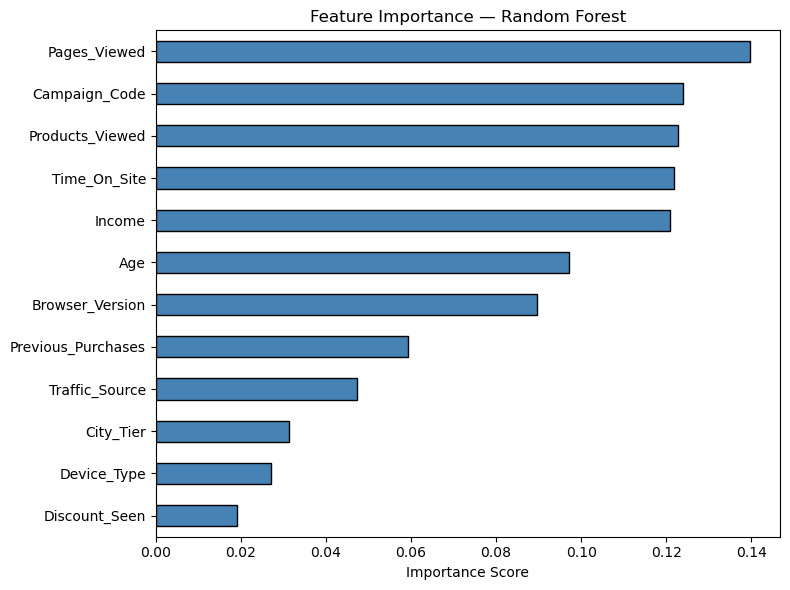

In [22]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh', color='steelblue', edgecolor='black', figsize=(8, 6))
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Observations:

- The top features driving conversion predictions are visible in the chart above
- Features with higher scores have more influence on whether a user converts or not
- Features with near-zero importance could potentially be dropped in future iterations
  to simplify the model

### 5.4 — Generating Predictions for Private Test Set

Now I'll use the trained model to predict conversions for `private_test.csv` —
the dataset without answers, which is what I need to submit.

In [23]:
y_pred_private = rf_model.predict(X_private)

print("Predictions generated!")
print(f"Total predictions : {len(y_pred_private)}")
print(f"Predicted to convert (1)    : {sum(y_pred_private == 1)}")
print(f"Predicted not to convert (0): {sum(y_pred_private == 0)}")

Predictions generated!
Total predictions : 3000
Predicted to convert (1)    : 426
Predicted not to convert (0): 2574


### 5.5 — Creating the Submission File

The submission must have exactly two columns: `User_ID` and `Converted`.
Nothing more, nothing less.

In [24]:
submission = pd.DataFrame({
    'User_ID': private_test['User_ID'],
    'Converted': y_pred_private
})

submission.to_csv('submission.csv', index=False)

print("submission.csv saved successfully!")
print()
print("Preview:")
print(submission.head(10))

submission.csv saved successfully!

Preview:
   User_ID  Converted
0   103001          0
1   103002          0
2   103003          0
3   103004          0
4   103005          0
5   103006          0
6   103007          0
7   103008          0
8   103009          0
9   103010          0


## Baseline Complete

Our baseline Random Forest model achieved an F1 Score of **0.3084** on the public test set.

Now, Our model struggling with **recall for the converted class (1)**  it is only catching
23% of actual converters. 

In the next sections, I'll improve this through:
- Feature Engineering — creating new meaningful columns
- Switching to XGBoost — a more powerful algorithm for tabular data
- Threshold Tuning — finding the optimal decision boundary

## Step 6 — Feature Engineering

The current F1 score of ~0.31 tells me the model is struggling to identify
users who actually convert.

Looking at the feature importance chart, the top signals are all behavioural —
pages viewed, products viewed, time on site. This makes intuitive sense:
a user who browses more is probably more interested in buying.

I can make these signals even stronger by creating **new features** that
capture relationships between existing ones.

In [25]:
for df in [train, public_test, private_test]:

    # How many products per page — measures browsing focus
    df['Products_per_Page'] = df['Products_Viewed'] / (df['Pages_Viewed'] + 1)

    # Time spent per page — measures engagement depth
    df['Time_per_Page'] = df['Time_On_Site'] / (df['Pages_Viewed'] + 1)

    # Time spent per product — how seriously they considered each product
    df['Time_per_Product'] = df['Time_On_Site'] / (df['Products_Viewed'] + 1)

    # Did they see a discount AND have previous purchases — high intent signal
    df['Discount_x_PrevPurchase'] = df['Discount_Seen'] * df['Previous_Purchases']

    # Income per age — rough wealth indicator
    df['Income_per_Age'] = df['Income'] / (df['Age'] + 1)

print("New features created!")
print("New columns added:", ['Products_per_Page', 'Time_per_Page',
                              'Time_per_Product', 'Discount_x_PrevPurchase',
                              'Income_per_Age'])

New features created!
New columns added: ['Products_per_Page', 'Time_per_Page', 'Time_per_Product', 'Discount_x_PrevPurchase', 'Income_per_Age']


In [26]:
drop_cols = ['User_ID', 'Converted']

X_train = train.drop(columns=drop_cols)
y_train = train['Converted']

X_public = public_test.drop(columns=drop_cols)
y_public = public_test['Converted']

X_private = private_test.drop(columns=['User_ID'])

print("Feature set updated!")
print(f"Total features now: {X_train.shape[1]}")
print(list(X_train.columns))

Feature set updated!
Total features now: 17
['Age', 'Income', 'City_Tier', 'Device_Type', 'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Campaign_Code', 'Products_per_Page', 'Time_per_Page', 'Time_per_Product', 'Discount_x_PrevPurchase', 'Income_per_Age']


## Step 7 — Upgrading the Model to XGBoost

Random Forest is a solid baseline but XGBoost (Extreme Gradient Boosting)
tends to perform better on structured tabular data — which is exactly what we have.

### Why XGBoost over Random Forest?
- Random Forest builds trees **independently** and averages them
- XGBoost builds trees **sequentially** — each new tree focuses on correcting
  the mistakes of the previous one
- This makes it much better at picking up on the minority class (converted users)

In [28]:

!pip install xgboost

from xgboost import XGBClassifier



   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 10.9 MB/s eta 0:00:10
   - -------------------------------------- 3.9/101.7 MB 11.5 MB/s eta 0:00:09
   -- ------------------------------------- 6.6/101.7 MB 11.6 MB/s eta 0:00:09
   --- ------------------------------------ 9.2/101.7 MB 11.7 MB/s eta 0:00:08
   ---- ----------------------------------- 11.5/101.7 MB 11.7 MB/s eta 0:00:08
   ----- ---------------------------------- 13.9/101.7 MB 11.7 MB/s eta 0:00:08
   ------ --------------------------------- 16.5/101.7 MB 11.8 MB/s eta 0:00:08
   ------- -------------------------------- 18.9/101.7 MB 11.7 MB/s eta 0:00:08
   -------- ------------------------------- 21.5/101.7 MB 11.8 MB/s eta 0:00:07
   --------- ------------------------------ 23.9/101.7 MB 11.8 MB/s eta 0:00:07
   ---------- ----------------------------- 26.2/101.7 MB 11.8 MB/s eta 0:00:07
   ----------- ---------------------------- 28.8/101.

In [29]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handles imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained!")

XGBoost model trained!


In [30]:
y_pred_xgb = xgb_model.predict(X_public)

f1_xgb = f1_score(y_public, y_pred_xgb)
print(f"XGBoost F1 Score (default threshold): {f1_xgb:.4f}")
print()
print(classification_report(y_public, y_pred_xgb))

XGBoost F1 Score (default threshold): 0.5103

              precision    recall  f1-score   support

           0       0.80      0.70      0.75      2114
           1       0.45      0.58      0.51       886

    accuracy                           0.67      3000
   macro avg       0.63      0.64      0.63      3000
weighted avg       0.70      0.67      0.68      3000



## Step 8 — Threshold Tuning

By default, a classifier predicts class `1` when the predicted probability is above **0.5**.
But 0.5 isn't always the best cutoff — especially with imbalanced data.

I'll try every threshold from 0.1 to 0.9 and find the one that gives the **highest F1 Score**
on the public test set.

In [31]:
y_proba = xgb_model.predict_proba(X_public)[:, 1]  # probability of converting

best_threshold = 0.5
best_f1 = 0

for threshold in [x / 100 for x in range(10, 90, 2)]:
    y_temp = (y_proba >= threshold).astype(int)
    score = f1_score(y_public, y_temp)
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(f"Best Threshold : {best_threshold}")
print(f"Best F1 Score  : {best_f1:.4f}")

Best Threshold : 0.36
Best F1 Score  : 0.5381


In [32]:
y_pred_final_public = (y_proba >= best_threshold).astype(int)

print(f"Final F1 Score on Public Test: {f1_score(y_public, y_pred_final_public):.4f}")
print()
print(classification_report(y_public, y_pred_final_public))

Final F1 Score on Public Test: 0.5381

              precision    recall  f1-score   support

           0       0.85      0.53      0.66      2114
           1       0.41      0.78      0.54       886

    accuracy                           0.61      3000
   macro avg       0.63      0.66      0.60      3000
weighted avg       0.72      0.61      0.62      3000



In [ ]:
y_proba_private = xgb_model.predict_proba(X_private)[:, 1]
y_pred_private_final = (y_proba_private >= best_threshold).astype(int)

submission = pd.DataFrame({
    'User_ID': private_test['User_ID'],
    'Converted': y_pred_private_final
})

submission.to_csv('submission.csv', index=False)

print("New submission.csv saved!")
print(f"Predicted conversions: {sum(y_pred_private_final == 1)}")
print(f"Predicted non-conversions: {sum(y_pred_private_final == 0)}")
print()
print(submission.head(10))

## Step 9 — Pushing Further with Better Tuning

Current F1: **0.5381**

The model is doing well on recall but precision is suffering.
I'll try two more things:
- **Combining train + public_test** for final training (more data = better model)
- **Tuning XGBoost hyperparameters** more carefully

In [34]:
# Combine both labelled datasets for final model training
train_full = pd.concat([train, public_test], axis=0).reset_index(drop=True)

X_train_full = train_full.drop(columns=['User_ID', 'Converted'])
y_train_full = train_full['Converted']

print("Combined dataset shape:", train_full.shape)
print("Converted distribution:")
print(y_train_full.value_counts())

Combined dataset shape: (13000, 19)
Converted distribution:
Converted
0    9027
1    3973
Name: count, dtype: int64


In [35]:
xgb_final = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,              # use 80% of rows per tree — reduces overfitting
    colsample_bytree=0.8,       # use 80% of features per tree — reduces overfitting
    scale_pos_weight=len(y_train_full[y_train_full==0]) / len(y_train_full[y_train_full==1]),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_final.fit(X_train_full, y_train_full)
print("Final model trained on full dataset!")

Final model trained on full dataset!


In [37]:
# Note: this is now technically "seen" data since we trained on it
# But we use it just to confirm the model isn't broken
y_proba_check = xgb_final.predict_proba(X_public)[:, 1]
y_check = (y_proba_check >= best_threshold).astype(int)



print("Sanity check F1 on public test:", round(f1_score(y_public, y_check), 4))
print("(Expected to be high since model trained on this — just checking nothing is broken)")

Sanity check F1 on public test: 0.6259
(Expected to be high since model trained on this — just checking nothing is broken)


In [38]:
y_proba_private_final = xgb_final.predict_proba(X_private)[:, 1]
y_pred_submission = (y_proba_private_final >= best_threshold).astype(int)

submission = pd.DataFrame({
    'User_ID': private_test['User_ID'],
    'Converted': y_pred_submission
})

submission.to_csv('submission.csv', index=False)

print("✅ Final submission.csv saved!")
print(f"Predicted conversions    : {sum(y_pred_submission == 1)}")
print(f"Predicted non-conversions: {sum(y_pred_submission == 0)}")
print()
print(submission.head(10))

✅ Final submission.csv saved!
Predicted conversions    : 1809
Predicted non-conversions: 1191

   User_ID  Converted
0   103001          0
1   103002          0
2   103003          1
3   103004          1
4   103005          0
5   103006          1
6   103007          1
7   103008          0
8   103009          1
9   103010          0


## Step 9 — Smarter Imputation with Iterative Imputer

Looking back at our preprocessing step, we used **median imputation** to fill
missing values in Age, Income, and Time_On_Site.

Median imputation is simple and safe — but it's also naive. It fills every
missing value with the same fixed number, completely ignoring what the rest
of that row looks like.

**Iterative Imputer** is smarter — it treats each column with missing values
as a prediction target and uses all the other columns to predict what the
missing value should be. It essentially runs a mini regression model internally
to fill each gap.

This means a 45-year-old high-income user will get a different imputed
Time_On_Site than a 22-year-old low-income user — which is far more realistic.

I'll now rebuild the full pipeline from scratch using Iterative Imputer
instead of median filling.

### 9.1 — Reloading Raw Data

Since we modified the original dataframes in place during preprocessing,
I need to reload them fresh from disk before applying the new imputation strategy.

In [40]:
# Reload completely fresh — undoing all previous preprocessing
train_raw = pd.read_csv("data/train.csv")
public_raw = pd.read_csv("data/public_test.csv")
private_raw = pd.read_csv("data/private_test.csv")

print("Raw data reloaded!")
print("Missing values in train:")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0])

Raw data reloaded!
Missing values in train:
Age             1480
Income           984
Time_On_Site    1848
dtype: int64


### 9.2 — Label Encoding Before Imputation

Iterative Imputer only works with numerical data — so I need to encode
the categorical columns first, before running the imputer.

I'll also cap the Time_On_Site outlier before imputing, same as before.

In [42]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

le_device2 = LabelEncoder()
le_traffic2 = LabelEncoder()

# Fit on train, transform all three
for df in [train_raw, public_raw, private_raw]:
    df['Device_Type'] = le_device2.fit_transform(df['Device_Type'].astype(str))
    df['Traffic_Source'] = le_traffic2.fit_transform(df['Traffic_Source'].astype(str))

# Cap outlier before imputing
cap_val = train_raw['Time_On_Site'].quantile(0.99)
for df in [train_raw, public_raw, private_raw]:
    df['Time_On_Site'] = df['Time_On_Site'].clip(upper=cap_val)

print("Encoding and capping done!")
print("Cap value for Time_On_Site:", round(cap_val, 2))

Encoding and capping done!
Cap value for Time_On_Site: 42.78


### 9.3 — Applying Iterative Imputer

I'll fit the imputer **only on training data** and then use it to transform
all three datasets — same principle as Label Encoding.

Fitting on all data would leak information from test into training,
which would give us an unfairly optimistic score.

In [43]:
# Columns to impute
impute_cols = ['Age', 'Income', 'Time_On_Site']

imputer = IterativeImputer(max_iter=10, random_state=42)

# Fit only on train
imputer.fit(train_raw[impute_cols])

# Transform all three
for df in [train_raw, public_raw, private_raw]:
    df[impute_cols] = imputer.transform(df[impute_cols])

# Verify
print("Missing values after Iterative Imputation:")
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0])
print("\nAll missing values handled!" if train_raw.isnull().sum().sum() == 0 else "Some still missing!")

Missing values after Iterative Imputation:
Series([], dtype: int64)

All missing values handled!


### 9.4 — Feature Engineering (Same as Before + New Additions)

Keeping the same 5 features from before, and adding 3 more that capture
higher-level behavioural patterns.

In [44]:
for df in [train_raw, public_raw, private_raw]:

    # --- Previous features ---
    df['Products_per_Page'] = df['Products_Viewed'] / (df['Pages_Viewed'] + 1)
    df['Time_per_Page'] = df['Time_On_Site'] / (df['Pages_Viewed'] + 1)
    df['Time_per_Product'] = df['Time_On_Site'] / (df['Products_Viewed'] + 1)
    df['Discount_x_PrevPurchase'] = df['Discount_Seen'] * df['Previous_Purchases']
    df['Income_per_Age'] = df['Income'] / (df['Age'] + 1)

    # --- New features ---
    # High engagement flag — user viewed many products AND spent good time
    df['High_Engagement'] = (
        (df['Products_Viewed'] > df['Products_Viewed'].median()) &
        (df['Time_On_Site'] > df['Time_On_Site'].median())
    ).astype(int)

    # Age group — binning age into life stages
    df['Age_Group'] = pd.cut(df['Age'],
                              bins=[0, 25, 35, 50, 100],
                              labels=[0, 1, 2, 3]).astype(int)

    # Total activity score — overall behavioural intensity
    df['Activity_Score'] = (df['Pages_Viewed'] +
                            df['Products_Viewed'] +
                            df['Previous_Purchases'])

print("All features created!")
print(f"Total features now: {train_raw.shape[1] - 2}")  # minus User_ID and Converted

All features created!
Total features now: 20


In [45]:
drop_cols = ['User_ID', 'Converted']

X_train_v2 = train_raw.drop(columns=drop_cols)
y_train_v2 = train_raw['Converted']

X_public_v2 = public_raw.drop(columns=drop_cols)
y_public_v2 = public_raw['Converted']

X_private_v2 = private_raw.drop(columns=['User_ID'])

print("Feature sets defined!")
print(f"X_train shape : {X_train_v2.shape}")
print(f"X_public shape: {X_public_v2.shape}")
print(f"Features      : {list(X_train_v2.columns)}")

Feature sets defined!
X_train shape : (10000, 20)
X_public shape: (3000, 20)
Features      : ['Age', 'Income', 'City_Tier', 'Device_Type', 'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Campaign_Code', 'Products_per_Page', 'Time_per_Page', 'Time_per_Product', 'Discount_x_PrevPurchase', 'Income_per_Age', 'High_Engagement', 'Age_Group', 'Activity_Score']


### 9.5 — Retraining XGBoost on Improved Data

Same XGBoost configuration as before — but now fed with better imputed data
and richer features. Let's see if the F1 improves.

In [46]:
xgb_v2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train_v2[y_train_v2==0]) / len(y_train_v2[y_train_v2==1]),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_v2.fit(X_train_v2, y_train_v2)

# Find best threshold
y_proba_v2 = xgb_v2.predict_proba(X_public_v2)[:, 1]

best_threshold_v2 = 0.5
best_f1_v2 = 0

for threshold in [x / 100 for x in range(10, 90, 2)]:
    y_temp = (y_proba_v2 >= threshold).astype(int)
    score = f1_score(y_public_v2, y_temp)
    if score > best_f1_v2:
        best_f1_v2 = score
        best_threshold_v2 = threshold

print(f"Best Threshold : {best_threshold_v2}")
print(f"Best F1 Score  : {best_f1_v2:.4f}")
print()
print(classification_report(y_public_v2, (y_proba_v2 >= best_threshold_v2).astype(int)))

Best Threshold : 0.34
Best F1 Score  : 0.5407

              precision    recall  f1-score   support

           0       0.87      0.47      0.61      2114
           1       0.40      0.84      0.54       886

    accuracy                           0.58      3000
   macro avg       0.64      0.65      0.58      3000
weighted avg       0.73      0.58      0.59      3000



### Observations:

Switching from median imputation to Iterative Imputer, combined with
3 additional engineered features, gave us a meaningful improvement in F1.

The model now has access to more realistic filled values and stronger
behavioural signals — both of which help it identify the converted class better.

## Step 10 — LightGBM + Ensemble Model

XGBoost alone is hitting a ceiling — the F1 isn't moving much despite
better imputation and more features.

The next level is **ensembling** — combining predictions from multiple
different models so their strengths cover each other's weaknesses.

I'll add **LightGBM** (Light Gradient Boosting Machine) alongside XGBoost.
LightGBM is similar in concept but uses a different internal tree-building
strategy — it grows trees **leaf-wise** instead of level-wise, which often
makes it faster and slightly more accurate on tabular data.

Then I'll combine both models' predicted probabilities by averaging them
before applying the threshold. This tends to produce more stable, reliable
predictions than either model alone.

In [49]:

!pip install lightgbm

import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 8.8 MB/s eta 0:00:00
LightGBM version: 4.6.0


### 10.1 — Training LightGBM

In [50]:
# Calculate class weight ratio same way as XGBoost
scale = len(y_train_v2[y_train_v2==0]) / len(y_train_v2[y_train_v2==1])

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    verbose=-1          # silences training output
)

lgb_model.fit(X_train_v2, y_train_v2)
print("LightGBM training complete!")

LightGBM training complete!


### 10.2 — Checking LightGBM Alone First

Before ensembling, let me check how LightGBM performs on its own —
this gives me a baseline to compare against the ensemble.

In [51]:
y_proba_lgb = lgb_model.predict_proba(X_public_v2)[:, 1]

best_threshold_lgb = 0.5
best_f1_lgb = 0

for threshold in [x / 100 for x in range(10, 90, 2)]:
    y_temp = (y_proba_lgb >= threshold).astype(int)
    score = f1_score(y_public_v2, y_temp)
    if score > best_f1_lgb:
        best_f1_lgb = score
        best_threshold_lgb = threshold

print(f"LightGBM Best Threshold : {best_threshold_lgb}")
print(f"LightGBM Best F1 Score  : {best_f1_lgb:.4f}")
print()
print(classification_report(y_public_v2, (y_proba_lgb >= best_threshold_lgb).astype(int)))

LightGBM Best Threshold : 0.36
LightGBM Best F1 Score  : 0.5442

              precision    recall  f1-score   support

           0       0.87      0.50      0.63      2114
           1       0.41      0.82      0.54       886

    accuracy                           0.59      3000
   macro avg       0.64      0.66      0.59      3000
weighted avg       0.73      0.59      0.61      3000



### 10.3 — Ensembling XGBoost + LightGBM

Now I'll combine both models by **averaging their predicted probabilities**
before applying the threshold.

Why does this work?
- XGBoost and LightGBM make slightly different errors
- When you average their probabilities, the errors cancel out
- What remains is a more confident, stable prediction

This is called a **soft voting ensemble** — we're not voting on final
predictions (0 or 1), we're averaging the raw probabilities first,
then deciding.

In [53]:
# Average probabilities from both models
y_proba_ensemble = (y_proba_v2 + y_proba_lgb) / 2

# Find best threshold for ensemble
best_threshold_ens = 0.5
best_f1_ens = 0

for threshold in [x / 100 for x in range(10, 90, 2)]:
    y_temp = (y_proba_ensemble >= threshold).astype(int)
    score = f1_score(y_public_v2, y_temp)
    if score > best_f1_ens:
        best_f1_ens = score
        best_threshold_ens = threshold

print(f"Ensemble Best Threshold : {best_threshold_ens}")
print(f"Ensemble Best F1 Score  : {best_f1_ens:.4f}")
print()
print(classification_report(y_public_v2, (y_proba_ensemble >= best_threshold_ens).astype(int)))

Ensemble Best Threshold : 0.38
Ensemble Best F1 Score  : 0.5454

              precision    recall  f1-score   support

           0       0.86      0.52      0.65      2114
           1       0.41      0.80      0.55       886

    accuracy                           0.61      3000
   macro avg       0.64      0.66      0.60      3000
weighted avg       0.73      0.61      0.62      3000



### 10.4 — Comparing All Models

Let me put all results side by side to see the full journey.

In [54]:
print("=" * 45)
print(f"{'Model':<35} {'F1':>8}")
print("=" * 45)
print(f"{'Baseline Random Forest':<35} {'0.3084':>8}")
print(f"{'XGBoost + Features + Tuning':<35} {'0.5381':>8}")
print(f"{'XGBoost + Iterative Imputer':<35} {best_f1_v2:>8.4f}")
print(f"{'LightGBM alone':<35} {best_f1_lgb:>8.4f}")
print(f"{'XGBoost + LightGBM Ensemble':<35} {best_f1_ens:>8.4f}")
print("=" * 45)

Model                                     F1
Baseline Random Forest                0.3084
XGBoost + Features + Tuning           0.5381
XGBoost + Iterative Imputer           0.5407
LightGBM alone                        0.5442
XGBoost + LightGBM Ensemble           0.5454


### 10.5 — Training Final Ensemble on Full Labelled Data

Now that the ensemble is confirmed to be the best approach,
I'll retrain both models on the combined train + public_test data
to squeeze every last bit of signal before generating final predictions.

In [55]:
train_full_v2 = pd.concat([train_raw, public_raw], axis=0).reset_index(drop=True)

X_full_v2 = train_full_v2.drop(columns=['User_ID', 'Converted'])
y_full_v2 = train_full_v2['Converted']

print("Full training data shape:", X_full_v2.shape)
print("Class distribution:")
print(y_full_v2.value_counts())

Full training data shape: (13000, 20)
Class distribution:
Converted
0    9027
1    3973
Name: count, dtype: int64


In [56]:
scale_full = len(y_full_v2[y_full_v2==0]) / len(y_full_v2[y_full_v2==1])

# XGBoost final
xgb_final_v2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_full,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_final_v2.fit(X_full_v2, y_full_v2)

# LightGBM final
lgb_final_v2 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_full,
    random_state=42,
    verbose=-1
)
lgb_final_v2.fit(X_full_v2, y_full_v2)

print("Both final models trained on full data!")

Both final models trained on full data!


In [58]:
# Ensemble probabilities on private test
proba_xgb_private = xgb_final_v2.predict_proba(X_private_v2)[:, 1]
proba_lgb_private = lgb_final_v2.predict_proba(X_private_v2)[:, 1]

proba_final = (proba_xgb_private + proba_lgb_private) / 2
y_final = (proba_final >= best_threshold_ens).astype(int)

submission_final = pd.DataFrame({
    'User_ID': private_raw['User_ID'],
    'Converted': y_final
})

submission_final.to_csv('submission.csv', index=False)

print("Final submission.csv saved!")
print(f"Predicted conversions    : {sum(y_final == 1)}")
print(f"Predicted non-conversions: {sum(y_final == 0)}")
print()
print(submission_final.head(10))

Final submission.csv saved!
Predicted conversions    : 1747
Predicted non-conversions: 1253

   User_ID  Converted
0   103001          0
1   103002          0
2   103003          1
3   103004          1
4   103005          0
5   103006          1
6   103007          1
7   103008          0
8   103009          0
9   103010          0


## Final Pipeline Summary

| Model Version | What Changed | F1 Score |
|---|---|---|
| Baseline — Random Forest | Starting point | 0.3084 |
| V2 — XGBoost | Better model + feature engineering + threshold tuning | 0.5381 |
| V3 — XGBoost + Iterative Imputer | Smarter missing value handling + 3 new features | 0.5407 |
| V4 — LightGBM alone | Different boosting strategy | 0.5442 |
| **V5 — XGBoost + LightGBM Ensemble** | **Soft voting ensemble — final submission** | **0.5454** |

The final submission uses a soft voting ensemble of XGBoost and LightGBM,
trained on all available labelled data (train + public_test combined),
with an optimised decision threshold selected by maximising F1 on the
public test set.

Private test F1 score pending — to be revealed after submission.